In [9]:
from pathlib import Path
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path(r"C:/Users/Rahul/OneDrive/Desktop/Learning/Projects/nyc_taxi")
PROCESSED_DIR = PROJECT_ROOT / "processed"

files = [
    PROCESSED_DIR / "yellow_taxi_2023_model_ready.parquet",
    PROCESSED_DIR / "yellow_taxi_2024_model_ready.parquet",
    PROCESSED_DIR / "yellow_taxi_2025_model_ready.parquet",
]

feature_cols = [
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_weekday",
    "pickup_month",
]

target_col = "fare_amount"

lf = pl.scan_parquet([str(f) for f in files]).select(
    ["tpep_pickup_datetime"] + feature_cols + [target_col]
)

train_lf = lf.filter(pl.col("tpep_pickup_datetime") < pl.datetime(2025, 1, 1))

valid_lf = lf.filter(
    (pl.col("tpep_pickup_datetime") >= pl.datetime(2025, 1, 1)) &
    (pl.col("tpep_pickup_datetime") < pl.datetime(2025, 7, 1))
)

test_lf = lf.filter(
    (pl.col("tpep_pickup_datetime") >= pl.datetime(2025, 7, 1)) &
    (pl.col("tpep_pickup_datetime") < pl.datetime(2025, 12, 1))
)

def split_summary(name, split_lf):
    return split_lf.select([
        pl.lit(name).alias("split"),
        pl.len().alias("row_count"),
        pl.col("tpep_pickup_datetime").min().alias("pickup_min"),
        pl.col("tpep_pickup_datetime").max().alias("pickup_max"),
    ]).collect()

summary = pl.concat([
    split_summary("train", train_lf),
    split_summary("valid", valid_lf),
    split_summary("test", test_lf),
])

summary

split,row_count,pickup_min,pickup_max
str,u32,datetime[μs],datetime[μs]
"""train""",76654965,2023-01-01 00:00:00,2024-12-31 23:59:58
"""valid""",21954351,2025-01-01 00:00:00,2025-06-30 23:59:59
"""test""",18041052,2025-07-01 00:00:00,2025-11-30 23:59:59


In [2]:
for split_name, split_lf in [("train", train_lf), ("valid", valid_lf), ("test", test_lf)]:
    print(f"\n=== Null counts for {split_name} ===")
    display(
        split_lf.select([
            pl.col(c).null_count().alias(c) for c in feature_cols + [target_col]
        ]).collect()
    )


=== Null counts for train ===


VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,pickup_hour,pickup_weekday,pickup_month,fare_amount
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,4695697,0,4695697,4695697,0,0,0,0,0,0



=== Null counts for valid ===


VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,pickup_hour,pickup_weekday,pickup_month,fare_amount
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,4168973,0,4168973,4168973,0,0,0,0,0,0



=== Null counts for test ===


VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,pickup_hour,pickup_weekday,pickup_month,fare_amount
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,3583935,0,3583935,3583935,0,0,0,0,0,0


# Printing all the column names

In [8]:
files = [
    PROCESSED_DIR / "yellow_taxi_2023_model_ready.parquet",
    PROCESSED_DIR / "yellow_taxi_2024_model_ready.parquet",
    PROCESSED_DIR / "yellow_taxi_2025_model_ready.parquet",
]

for file_path in files:
    lf = pl.scan_parquet(str(file_path))
    cols = lf.collect_schema().names()
    n_cols = len(cols)
    n_rows = lf.select(pl.len().alias("n_rows")).collect().item(0, 0)

    print(f"\n=== {file_path.name} ===")
    print("Shape:", (n_rows, n_cols))
    # print("Columns:")
    # for col in cols:
    #     print(col)


=== yellow_taxi_2023_model_ready.parquet ===
Shape: (37073303, 28)

=== yellow_taxi_2024_model_ready.parquet ===
Shape: (39581662, 28)

=== yellow_taxi_2025_model_ready.parquet ===
Shape: (39995403, 28)


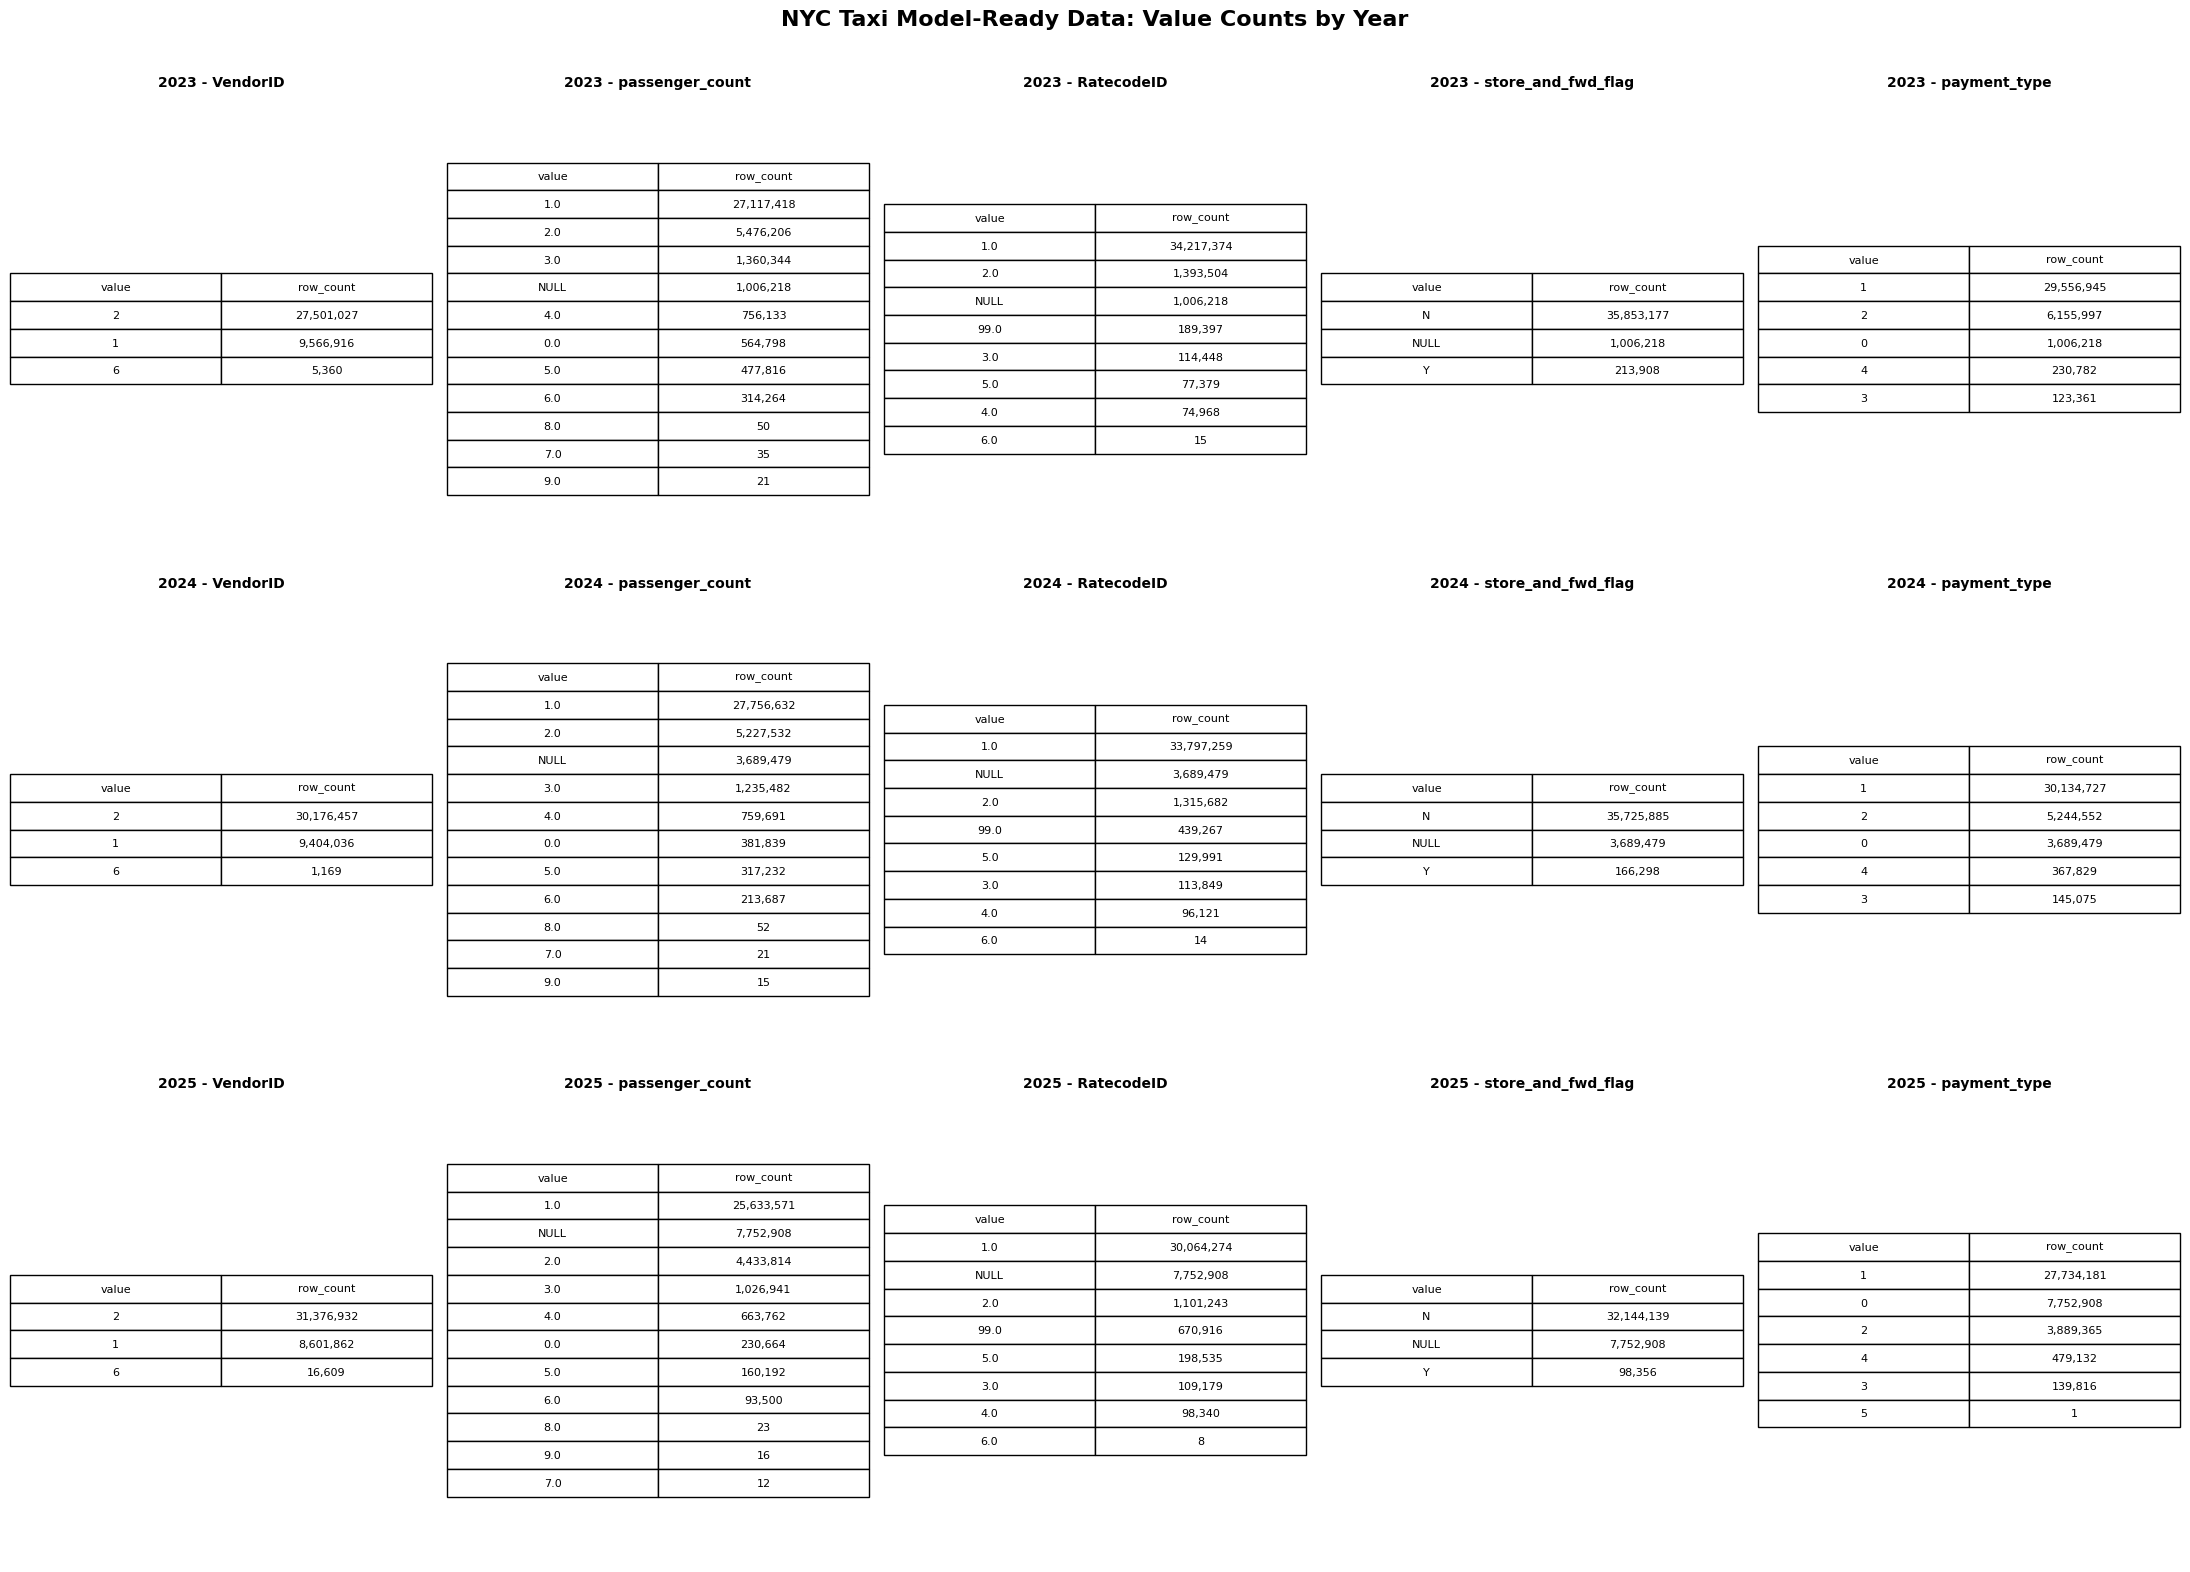

Saved image to: C:\Users\Rahul\OneDrive\Desktop\Learning\Projects\nyc_taxi\reports\data_quality\categorical_value_counts_by_year.jpg


In [11]:
PROJECT_ROOT = Path(r"C:/Users/Rahul/OneDrive/Desktop/Learning/Projects/nyc_taxi")
PROCESSED_DIR = PROJECT_ROOT / "processed"
REPORT_DIR = PROJECT_ROOT / "reports" / "data_quality"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

files = {
    2023: PROCESSED_DIR / "yellow_taxi_2023_model_ready.parquet",
    2024: PROCESSED_DIR / "yellow_taxi_2024_model_ready.parquet",
    2025: PROCESSED_DIR / "yellow_taxi_2025_model_ready.parquet",
}

cols_to_summarize = [
    "VendorID",
    "passenger_count",
    "RatecodeID",
    "store_and_fwd_flag",
    "payment_type",
]

def value_counts_with_nulls(file_path, col_name):
    df = (
        pl.scan_parquet(str(file_path))
        .with_columns(
            pl.when(pl.col(col_name).is_null())
            .then(pl.lit("NULL"))
            .otherwise(pl.col(col_name).cast(pl.Utf8))
            .alias(f"{col_name}_display")
        )
        .group_by(f"{col_name}_display")
        .agg(pl.len().alias("row_count"))
        .sort("row_count", descending=True)
        .collect()
        .to_pandas()
    )

    df["row_count_fmt"] = df["row_count"].map(lambda x: f"{x:,}")
    df = df.rename(columns={f"{col_name}_display": col_name})
    return df

summary_tables = {}

for year, file_path in files.items():
    summary_tables[year] = {}
    for col in cols_to_summarize:
        summary_tables[year][col] = value_counts_with_nulls(file_path, col)


summary_tables[2023]["payment_type"]

def draw_table(ax, df, title, col_name, max_rows=15):
    ax.axis("off")

    df_show = df.head(max_rows).copy()
    df_show = df_show[[col_name, "row_count_fmt"]]
    df_show.columns = ["value", "row_count"]

    table = ax.table(
        cellText=df_show.values,
        colLabels=df_show.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 1.3)

    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)

fig, axes = plt.subplots(
    nrows=3, ncols=5,
    figsize=(22, 16)
)

years = [2023, 2024, 2025]

for i, year in enumerate(years):
    for j, col in enumerate(cols_to_summarize):
        ax = axes[i, j]
        draw_table(
            ax=ax,
            df=summary_tables[year][col],
            title=f"{year} - {col}",
            col_name=col,
            max_rows=15
        )

plt.suptitle("NYC Taxi Model-Ready Data: Value Counts by Year", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])

out_path = REPORT_DIR / "categorical_value_counts_by_year.jpg"
plt.savefig(out_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"Saved image to: {out_path}")